What is required: 
- Poster that is 36 x 48 inches with min font size of 24pt
- describe support vecotr machine, including relevant equations, tuning paramers and considerations for application. No need to discuss precursor /simpler models to save space.
- Plot atleast one plot of an example SVM decision boundary on 2 strong predictor variables. This can be cartoon plot or plot of made up data, but you should demonstrate the type of plot and classification you are creating. 

- Discussion/Conclusions: Discuss which variables seemed to be strong predictors of disease. Given the interpretation of the SVM plots, what does this say about the habits or metrics that may impact diseases? If any demographic or social factors are used as predictors, how does this make sense? If you were to make a suggestion to policy-makers, what would you say, based off your findings?
- 
You must include the citation from the bottom of this assignment in your poster. 

## **Introduction**

Cancer is one of the most common and serious health conditions in the United States, affecting millions of people each year. While some risk factors, like genetics, are outside of an individual’s control, many others are related to everyday behaviors such as diet, physical activity, sleep, and substance use. Understanding how these factors are connected to cancer can help identify patterns that may be useful for prevention and early intervention.

In this project, I use data from the National Health Interview Survey (NHIS) to explore whether a person’s health habits and demographic characteristics can be used to predict whether they have ever been diagnosed with cancer. The dataset includes information on age, sex, education, health conditions, and a variety of lifestyle behaviors, making it well-suited for this type of analysis.

To approach this problem, I apply support vector machine (SVM) models with different kernel types (linear, radial, and polynomial). The goal is to compare how well these models perform and to see which variables appear to be most important in predicting cancer. Ultimately, this analysis aims to better understand the relationship between daily habits and cancer outcomes, and to explore how machine learning methods can be used in a public health context.

One could expect age and smoking frequency to be the strongest predictors of cancer diagnosis given their well-established links in epidemiological literature. 




Import the required libraries & dataset

In [73]:
library(e1071)
library(dplyr)
library(ggplot2)

In [86]:
nhis_df <- read.csv("https://raw.githubusercontent.com/mendible/5322/refs/heads/main/Homework%202/nhis_2022.csv")

head(nhis_df)

,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,⋯,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018,⋯,2,0,110,3,0,0,3,2,8,1
2,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117,⋯,1,0,1,0,0,1,1,1,6,2
3,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933,⋯,996,996,996,996,996,996,996,996,0,2
4,2022,3,134,13,0002022H000006,2,1,0002022H00000610,H000006,2681,⋯,1,1,1,0,2,0,1,1,6,2
5,2022,4,106,53,0002022H000007,3,1,0002022H00000710,H000007,10233,⋯,3,30,5,1,0,30,6,2,8,2
6,2022,4,106,53,0002022H000007,3,2,0002022H00000720,H000007,7712,⋯,996,996,996,996,996,996,996,996,0,1


### Data Cleaning & Preparation

##### Trget Variable and Predictor Selection

A meaningful variable name is also created as CANCEREV doesn't provide much meaning. 

##### Choosing the predictors & Target Variables

The target variable is CANCEREV, which records whether a respondent was ever diagnosed with cancer by a health professional. Valid responses are:

- 1 - No
- 2 - Yes
- 0,7,8,9 - NIU/Unknown(treated as missing)

For analysis purposes, only valid responses (1 = No and 2 = Yes) are typically used. All other categories (0, 7, 8, 9) are treated as missing or invalid responses because they do not provide reliable information about cancer status. To prepare the variable for modeling, it is often recoded into a binary format where “No” is coded as 0 and “Yes” is coded as 1.

The variable is recoded into a binary factor: 0 = No Cancer, 1 = Cancer. All invalid codes are set to NA.
The following variables are excluded from the analysis as they are survey identifiers or design components with no predictive value: YEAR, SERIAL, NHISPID, HHX, STRATA, PSU.
The selected predictors span three themes:
Demographics: Age, Sex, Poverty Ratio
Body Metrics: Weight
Lifestyle Habits: Alcohol consumption, Soda frequency, Sleep hours

In [88]:
library(dplyr)
# Recode target and predictors, setting invalid survey codes to NA
health_data_df <- nhis_df %>%
  mutate(
    # -----------------------------
    # TARGET VARIABLE (Cancer)
    # -----------------------------
  Cancer_Status = factor(
  ifelse(CANCEREV == 2, 1,
  ifelse(CANCEREV == 1, 0, NA)),  # ← correctly sends NIU/unknown to NA
  levels = c(0, 1),
  labels = c("No Cancer", "Cancer")
),

    # -----------------------------
    # DEMOGRAPHICS
    # -----------------------------
    Age_Years = ifelse(AGE %in% c(997, 998, 999), NA, AGE),

    Sex_Category = factor(
      ifelse(SEX %in% c(7, 8, 9), NA, SEX),
      levels = c(1, 2),
      labels = c("Male", "Female")
    ),

    Poverty_Ratio = ifelse(POVERTY %in% c(996, 997, 998, 999), NA, POVERTY),

    # -----------------------------
    # BODY METRICS
    # -----------------------------
    Weight_Lbs = ifelse(WEIGHT %in% c(0, 996, 997, 998), NA, WEIGHT),



    # -----------------------------
    # LIFESTYLE HABITS
    # -----------------------------
   

    Alcohol_Days = ifelse(ALCANYNO %in% c(996, 997, 998, 999), NA, ALCANYNO),

    Soda_Frequency = ifelse(SODAPNO %in% c(996, 997, 998, 999), NA, SODAPNO),

    Sleep_Hours = ifelse(HRSLEEP %in% c(0, 97, 98, 99), NA, HRSLEEP)
  )%>% #select the variables of interest
  select(Cancer_Status, Age_Years, Sex_Category, Poverty_Ratio,
         Weight_Lbs, Alcohol_Days, Soda_Frequency, Sleep_Hours)


Rename the variables

In [87]:
# health_data_df <- health_data_df %>%
#   rename(
#     Cancer_Status = Cancer,
#     Age_Years = Age,
#     Sex_Category = Sex,
#     Poverty_Ratio = Poverty,
#     Weight_Lbs = Weight,
#     Smoking_Days = Smoking,
#     Alcohol_Days = Alcohol,
#     Soda_Frequency = Soda,
#     Sleep_Hours = Sleep
#   )

Note that BMI was initially considered but it was excluded due to its collinearity with Weight — both capture body size, making them redundant as predictors. Smoking Days (CIGDAYMO) is excluded due to 34,421 missing values caused by a survey skip-pattern, as the question was only asked to some-day smokers, making reliable imputation infeasible.

To Assess Missing Values

In [77]:
colSums(is.na(health_data_df))

YEAR         SERIAL         STRATA            PSU        NHISHID 
             0              0              0              0              0 
        REGION         PERNUM        NHISPID            HHX     SAMPWEIGHT 
             0              0              0              0              0 
      ASTATFLG       CSTATFLG            AGE            SEX       MARSTCUR 
             0              0              0              0              0 
          EDUC       HOURSWRK        POVERTY         HEIGHT         WEIGHT 
             0              0              0              0              0 
       BMICALC      HINOTCOVE       CANCEREV     CHEARTDIEV     DIABETICEV 
             0              0              0              0              0 
    HEARTATTEV        STROKEV       ALCANYNO      ALCDAYSYR       CIGDAYMO 
             0              0              0              0              0 
     MOD10DMIN      VIG10DMIN         FRUTNO         VEGENO       JUICEMNO 
             0              0              0              0              0 
      SALADSNO         BEANNO       SALSAMNO    TOMSAUCEMNO        SODAPNO 
             0              0              0              0              0 
      FRIESPNO      SPORDRMNO    FRTDRINKMNO     COFETEAMNO       POTATONO 
             0              0              0              0              0 
       PIZZANO        HRSLEEP         CVDSHT cancer_history  Cancer_Status 
             0              0              0           7501              0 
     Age_Years   Sex_Category  Poverty_Ratio     Weight_Lbs   Smoking_Days 
            64              6              0           6373          34421 
  Alcohol_Days Soda_Frequency    Sleep_Hours 
         11550           8519           8436

Variables like 
* cancer_history: 7501
* Age_Years: 64
* Sex_Category: 6
*  Weight_Lbs: 6373
* Smoking_Days: 34421
* Alcohol_Days: 11550
* Soda_Frequency: 8519
* Sleep_Hours: 8436

Variables with very few missing values (Age_Years, Sex_Category) are handled by dropping those rows, as they represent a negligible fraction of the dataset. The target variable Cancer_Status rows with missing values are dropped entirely, as unknown cancer status cannot be reliably inferred. For continuous predictors with moderate missingness, median imputation is applied due to its robustness to skewed distributions common in survey data.

To inform our imputation strategy, we examine the distribution of each variable with missing values:

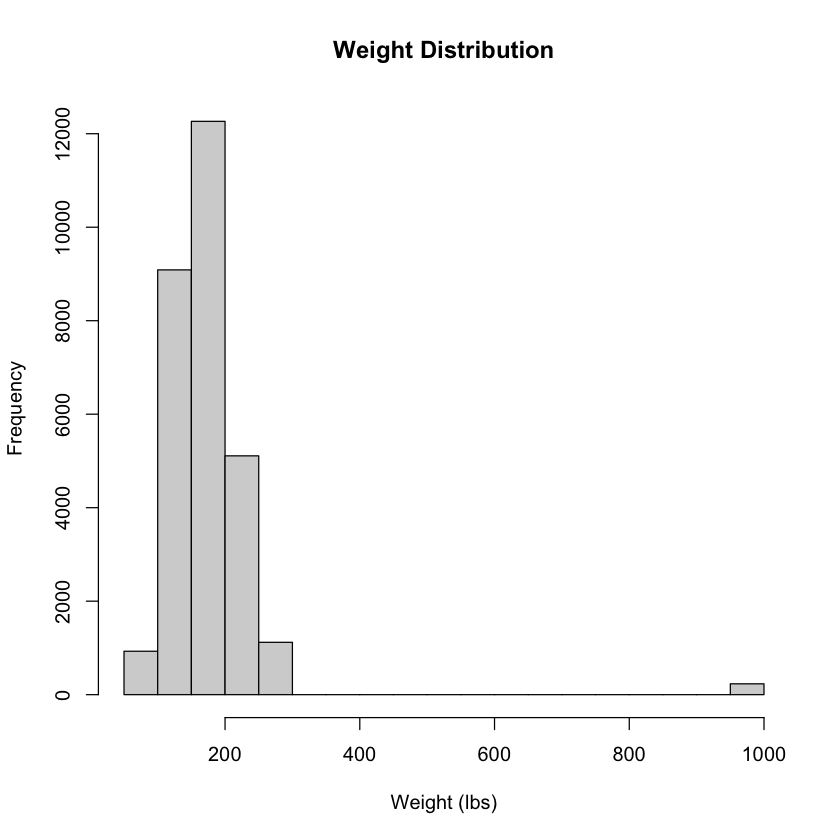

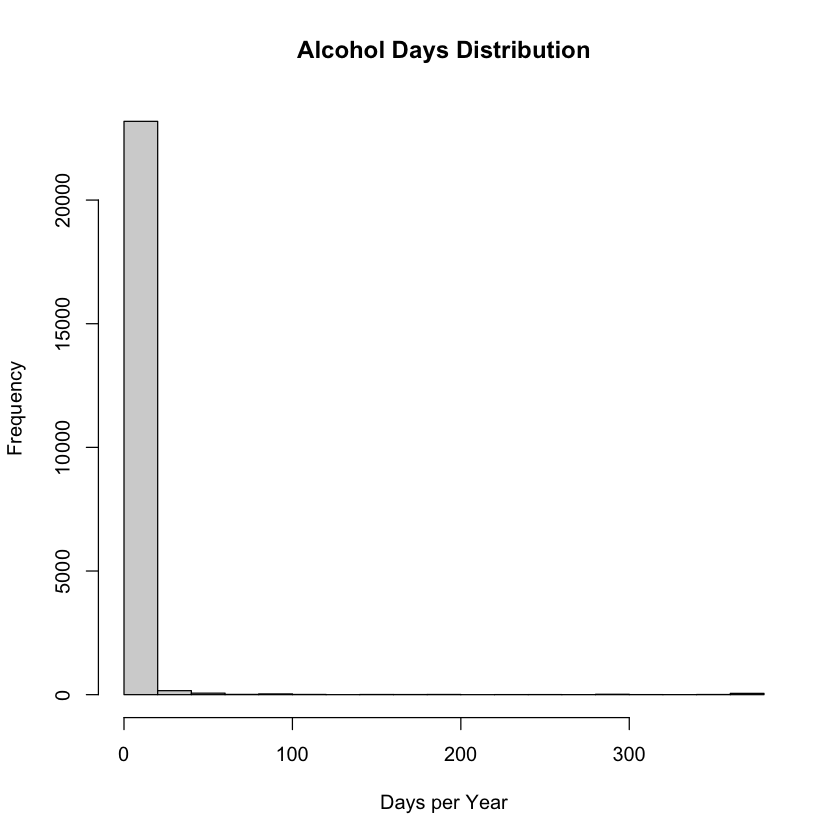

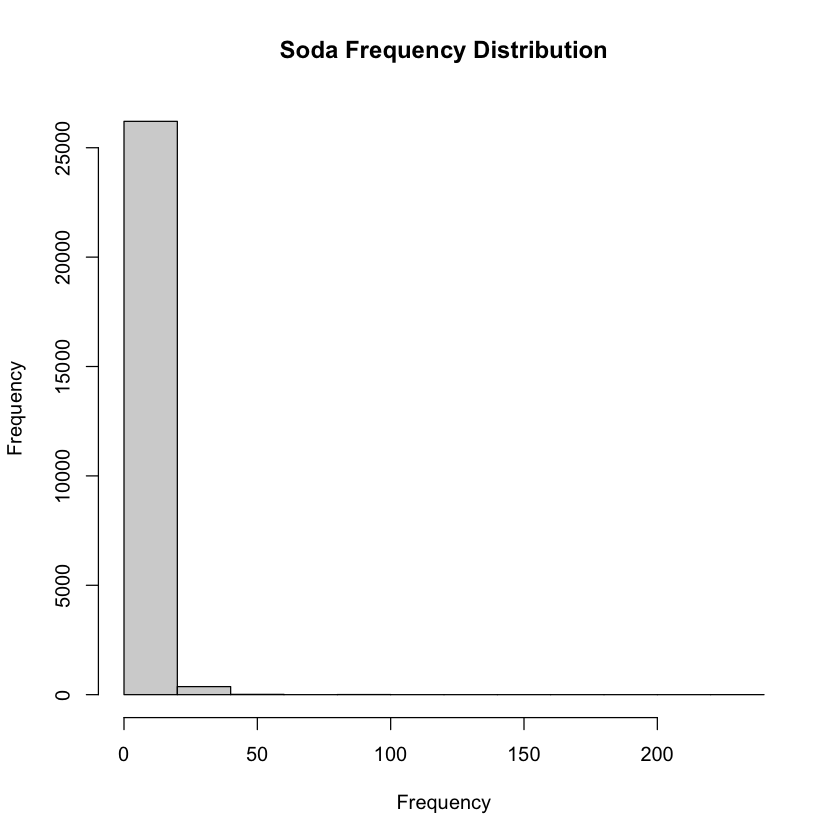

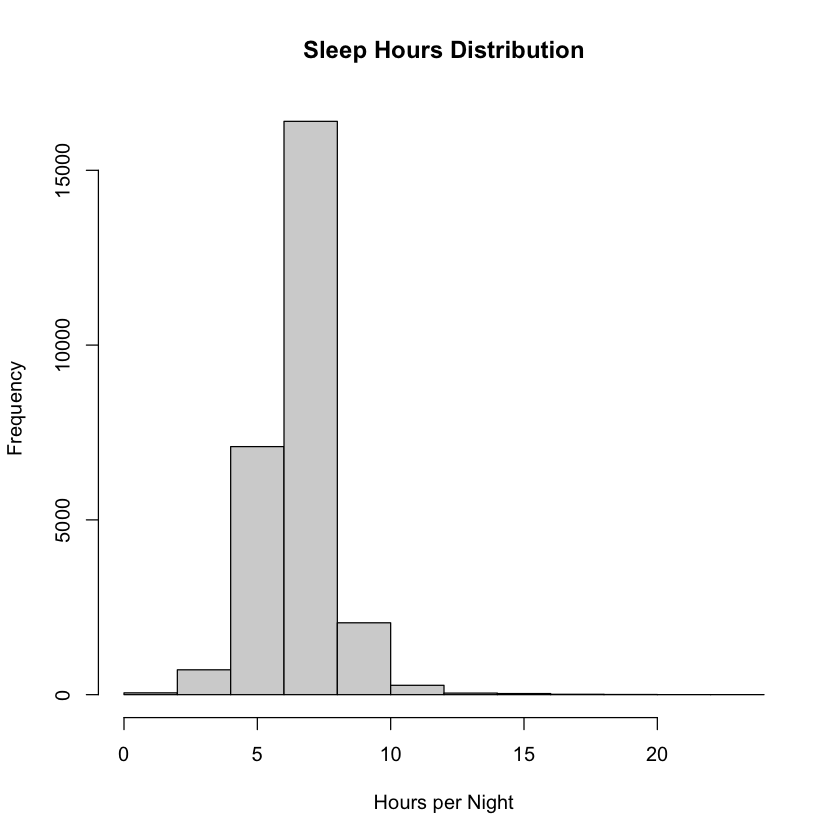

In [89]:
# Visualize distributions to determine imputation method
hist(health_data_df$Weight_Lbs,     main = "Weight Distribution",         xlab = "Weight (lbs)")
hist(health_data_df$Alcohol_Days,   main = "Alcohol Days Distribution",    xlab = "Days per Year")
hist(health_data_df$Soda_Frequency, main = "Soda Frequency Distribution",  xlab = "Frequency")
hist(health_data_df$Sleep_Hours,    main = "Sleep Hours Distribution",      xlab = "Hours per Night")

Alcohol_Days and Soda_Frequency show pronounced right skew, while Weight_Lbs and Sleep_Hours are more symmetric. Median imputation is used for all four variables as it is robust to skewed distributions and outliers, which are common in survey data.

To Impute the Missing Values

In [90]:
# Impute skewed/moderate-NA variables with column median
# Drop remaining rows with NA in Age and Sex (fewer than 70 rows combined)
health_data_df <- health_data_df %>%
  mutate(
    Weight_Lbs     = ifelse(is.na(Weight_Lbs),     median(Weight_Lbs,     na.rm = TRUE), Weight_Lbs),
    Alcohol_Days   = ifelse(is.na(Alcohol_Days),   median(Alcohol_Days,   na.rm = TRUE), Alcohol_Days),
    Soda_Frequency = ifelse(is.na(Soda_Frequency), median(Soda_Frequency, na.rm = TRUE), Soda_Frequency),
    Sleep_Hours    = ifelse(is.na(Sleep_Hours),    median(Sleep_Hours,    na.rm = TRUE), Sleep_Hours)
  ) %>%
  na.omit()

# Verify no missing values remain
colSums(is.na(health_data_df))
nrow(health_data_df)

Cancer_Status      Age_Years   Sex_Category  Poverty_Ratio     Weight_Lbs 
             0              0              0              0              0 
  Alcohol_Days Soda_Frequency    Sleep_Hours 
             0              0              0

[1] 27549

##### Class Balance Check

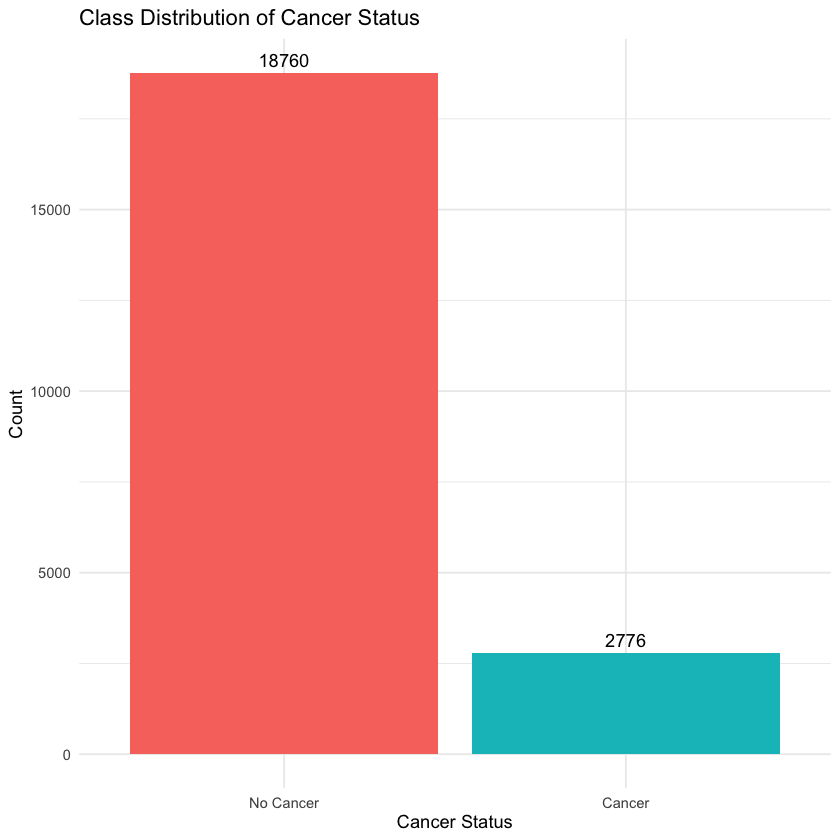

In [84]:
ggplot(health_data_df, aes(x = Cancer_Status, fill = Cancer_Status)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = ..count..), vjust = -0.5) +
  labs(
    title = "Class Distribution of Cancer Status",
    x = "Cancer Status",
    y = "Count"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

Cancer prevalence in the NHIS is typically around 10–12%, which creates class imbalance. If left unaddressed, models may be biased toward predicting "No Cancer" for all observations, inflating accuracy while failing to detect true cases.


## Modelling

#### Train/Test Split

In [91]:
#split data using 80:20 split
set.seed(2)
index <- sample(1:nrow(health_data_df), 0.8 * nrow(health_data_df))
train_df  <- health_data_df[index, ]
test_df   <- health_data_df[-index, ]

2. Use weighted classes

3. Fit and Tune Three SVM Models
One each for linear, radial, and polynomial kernels using tune().

4. Evaluate and Compare Models
Confusion matrices and accuracy for each kernel on the test set.

5. Plot a Decision Boundary
Required by the rubric — on two strong predictors.